[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/05_drift_and_judge_reliability.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/05_drift_and_judge_reliability.ipynb)

# Experiment 05: Drift & Judge Reliability Layer (Phase 5)

## Phase 5 Exploration — Validating Trust, Attribution, Behavioral Anchors, and Reporting

This notebook prototypes Phase 5 continuous evaluation and trust components before porting to `src/nirizan/`:
1. **Anchor Sets**: Human-labeled baseline reference distributions.
2. **Attribution Engine**: Disambiguating **System Drift** (application degradation) from **Judge Drift** (re-calibration shift).
3. **Behavioral Anchor Detector**: Embedding-based persona and constraint drift detection.
4. **System Health Score**: Aggregating score quality, confidence, and drift status into a composite metric.

### Prototyping Target `src/` Files
- `src/nirizan/trust/anchor_set.py`
- `src/nirizan/trust/attribution.py`
- `src/nirizan/metrics/behavioral_anchor.py`
- `src/nirizan/reporting/health_score.py`

### GPU Guidance
**CPU-only**: No GPU runtime required for this notebook.

## 1. Environment Setup

Installs `nirizan` from `main` to build against current contracts and models.

In [1]:
!pip install -q "pydantic>=2.7" "numpy" "scipy" \
    "git+https://github.com/Red1-Rahman/NiriZan.git@main#egg=nirizan"

from __future__ import annotations

import math
from datetime import datetime, timezone
from enum import Enum
from uuid import UUID, uuid4

import numpy as np
from pydantic import BaseModel, ConfigDict, Field

from nirizan.metrics.base import MetricResult

print("NiriZan Phase 5 drift & judge reliability components loaded.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
NiriZan Phase 5 drift & judge reliability components loaded.


## 2. Anchor Set Definition & Reference Distributions

Anchor sets maintain ground-truth distributions used to benchmark both system output quality and judge accuracy over time.

In [2]:
class AnchorItem(BaseModel):
    model_config = ConfigDict(strict=True)
    item_id: UUID = Field(default_factory=uuid4)
    input_text: str
    expected_output: str
    reference_scores: dict[str, float]


class AnchorSet(BaseModel):
    model_config = ConfigDict(strict=True)
    anchor_id: UUID = Field(default_factory=uuid4)
    name: str
    items: list[AnchorItem] = Field(default_factory=list)

    def get_reference_scores(self, metric_name: str) -> list[float]:
        scores = [
            item.reference_scores[metric_name]
            for item in self.items
            if metric_name in item.reference_scores
        ]
        if not scores:
            raise ValueError(f"Metric '{metric_name}' missing from anchor set.")
        return scores


anchor_set = AnchorSet(
    name="phase5-rag-anchor-v1",
    items=[
        AnchorItem(
            input_text="What is python?",
            expected_output="Language",
            reference_scores={"groundedness": 0.95},
        ),
        AnchorItem(
            input_text="What is rust?",
            expected_output="Systems language",
            reference_scores={"groundedness": 0.90},
        ),
        AnchorItem(
            input_text="Explain RAG.",
            expected_output="Retrieval Augmented Generation",
            reference_scores={"groundedness": 0.85},
        ),
    ],
)

ref_scores = anchor_set.get_reference_scores("groundedness")
assert len(ref_scores) == 3
assert np.mean(ref_scores) > 0.89
print(f"✅ AnchorSet loaded with {len(anchor_set.items)} items.")

✅ AnchorSet loaded with 3 items.


## 3. Attribution Engine: Disambiguating System vs. Judge Drift

Evaluates whether performance drops originate from system output degradation or judge calibration shifts.

In [3]:
class DriftState(str, Enum):
    NO_DRIFT = "no_drift"
    SYSTEM_DRIFT = "system_drift"
    JUDGE_DRIFT = "judge_drift"
    COMPOUND_DRIFT = "compound_drift"


class AttributionEngine:
    """Disambiguates System Drift from Judge Drift."""

    def __init__(
        self, judge_tolerance: float = 0.05, system_tolerance: float = 0.05
    ):
        self.judge_tolerance = judge_tolerance
        self.system_tolerance = system_tolerance

    def analyze(
        self,
        metric_name: str,
        anchor_set: AnchorSet,
        rescored_anchor_scores: list[float],
        prod_baseline_scores: list[float],
        prod_candidate_scores: list[float],
    ) -> DriftState:
        ref_scores = anchor_set.get_reference_scores(metric_name)

        judge_delta = abs(
            float(np.mean(rescored_anchor_scores)) - float(np.mean(ref_scores))
        )
        system_delta = abs(
            float(np.mean(prod_candidate_scores))
            - float(np.mean(prod_baseline_scores))
        )

        has_judge_drift = judge_delta > self.judge_tolerance
        has_system_drift = system_delta > self.system_tolerance

        if has_judge_drift and has_system_drift:
            return DriftState.COMPOUND_DRIFT
        if has_judge_drift:
            return DriftState.JUDGE_DRIFT
        if has_system_drift:
            return DriftState.SYSTEM_DRIFT
        return DriftState.NO_DRIFT


engine = AttributionEngine(judge_tolerance=0.05, system_tolerance=0.05)

# System Drift scenario
state_sys = engine.analyze(
    metric_name="groundedness",
    anchor_set=anchor_set,
    rescored_anchor_scores=[0.95, 0.90, 0.85],
    prod_baseline_scores=[0.92, 0.91, 0.89],
    prod_candidate_scores=[0.70, 0.65, 0.68],
)
assert state_sys == DriftState.SYSTEM_DRIFT

# Judge Drift scenario
state_judge = engine.analyze(
    metric_name="groundedness",
    anchor_set=anchor_set,
    rescored_anchor_scores=[0.75, 0.70, 0.65],
    prod_baseline_scores=[0.90, 0.89, 0.91],
    prod_candidate_scores=[0.89, 0.90, 0.88],
)
assert state_judge == DriftState.JUDGE_DRIFT

print("✅ AttributionEngine validated: correctly differentiates system vs judge drift.")

✅ AttributionEngine validated: correctly differentiates system vs judge drift.


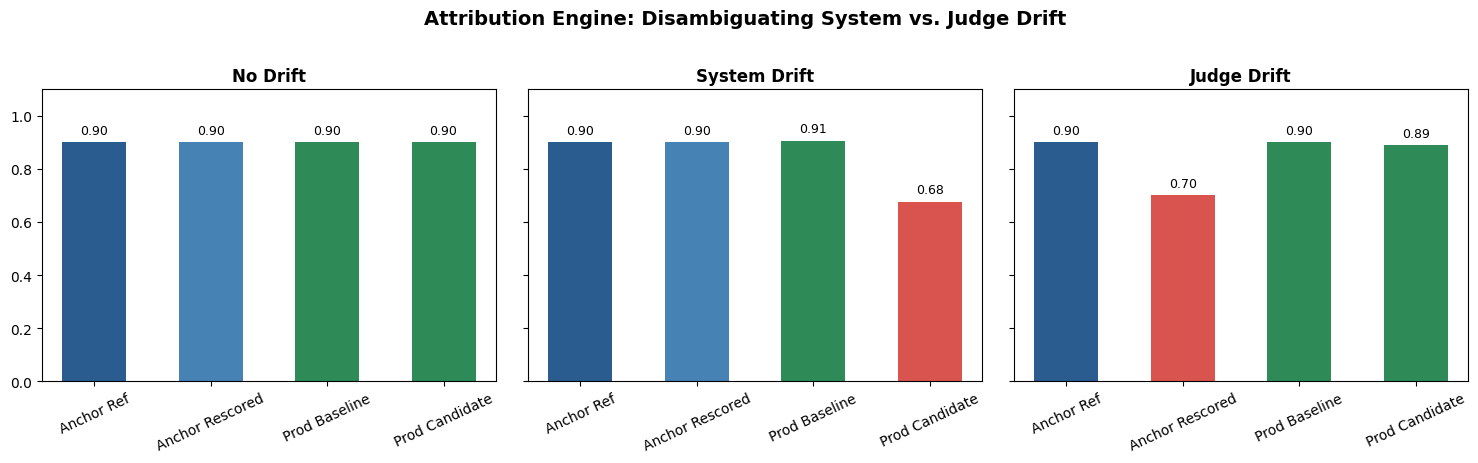

In [4]:
import matplotlib.pyplot as plt

# Comparison across drift scenarios
scenarios = {
    "No Drift": ([0.95, 0.90, 0.85], [0.95, 0.90, 0.85], [0.90, 0.90, 0.90], [0.90, 0.90, 0.90]),
    "System Drift": ([0.95, 0.90, 0.85], [0.95, 0.90, 0.85], [0.92, 0.91, 0.89], [0.70, 0.65, 0.68]),
    "Judge Drift": ([0.95, 0.90, 0.85], [0.75, 0.70, 0.65], [0.90, 0.89, 0.91], [0.89, 0.90, 0.88]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
categories = ["Anchor Ref", "Anchor Rescored", "Prod Baseline", "Prod Candidate"]

for ax, (title, (ref, rescored, base, cand)) in zip(axes, scenarios.items()):
    means = [np.mean(ref), np.mean(rescored), np.mean(base), np.mean(cand)]
    colors = ["#2b5c8f", "#4682b4" if abs(means[1]-means[0]) <= 0.05 else "#d9534f",
              "#2e8b57", "#2e8b57" if abs(means[3]-means[2]) <= 0.05 else "#d9534f"]

    bars = ax.bar(categories, means, color=colors, width=0.55)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=25)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Attribution Engine: Disambiguating System vs. Judge Drift", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Behavioral Anchor Detector: Agent Persona & Constraint Drift

Uses vector embeddings to detect semantic persona shifts or constraint violations against target vectors.

In [5]:
def cosine_similarity(u: np.ndarray, v: np.ndarray) -> float:
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0.0
    return float(np.dot(u, v) / (norm_u * norm_v))


class BehavioralAnchorDetector:
    """Measures persona or constraint drift via response vector similarity."""

    def __init__(
        self, target_embedding: np.ndarray, similarity_threshold: float = 0.85
    ):
        self.target_embedding = target_embedding
        self.similarity_threshold = similarity_threshold

    def evaluate_response(
        self, response_embedding: np.ndarray
    ) -> tuple[float, bool]:
        sim = cosine_similarity(self.target_embedding, response_embedding)
        is_drifted = sim < self.similarity_threshold
        return sim, is_drifted


target_persona = np.array([1.0, 0.0, 0.5])
aligned_response = np.array([0.98, 0.02, 0.49])
drifted_response = np.array([0.10, 0.90, -0.20])

detector = BehavioralAnchorDetector(
    target_persona, similarity_threshold=0.85
)

sim_a, is_drifted_a = detector.evaluate_response(aligned_response)
sim_d, is_drifted_d = detector.evaluate_response(drifted_response)

assert not is_drifted_a and sim_a >= 0.85
assert is_drifted_d and sim_d < 0.85

print(
    f"✅ BehavioralAnchorDetector validated (aligned_sim={sim_a:.4f}, drifted_sim={sim_d:.4f})."
)

✅ BehavioralAnchorDetector validated (aligned_sim=0.9998, drifted_sim=0.0000).


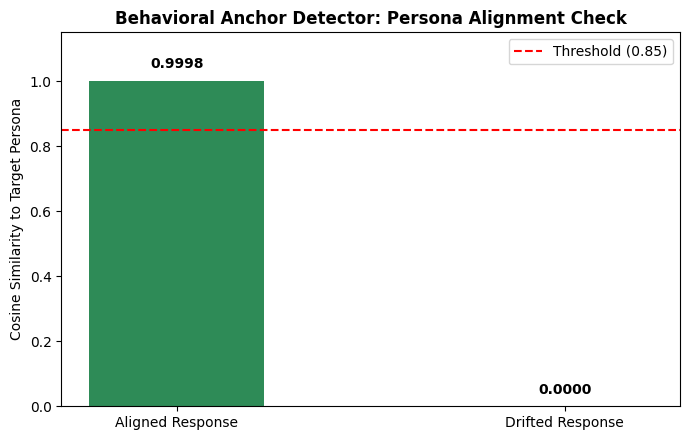

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

labels = ["Aligned Response", "Drifted Response"]
similarities = [sim_a, sim_d]
colors = ["#2e8b57" if not is_drifted_a else "#d9534f", "#d9534f" if is_drifted_d else "#2e8b57"]

bars = ax.bar(labels, similarities, color=colors, width=0.45)
ax.axhline(detector.similarity_threshold, color="red", linestyle="--", linewidth=1.5, label=f"Threshold ({detector.similarity_threshold})")

ax.set_ylabel("Cosine Similarity to Target Persona")
ax.set_ylim(0, 1.15)
ax.set_title("Behavioral Anchor Detector: Persona Alignment Check", fontweight="bold", fontsize=12)
ax.legend(loc="upper right")

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.03, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Composite Metric: System Health Score

Aggregates raw quality scores, statistical confidence, and attribution drift states into a single 0–100 operational metric.

In [7]:
def compute_system_health_score(
    mean_quality_score: float,
    statistical_confidence: float,
    attribution_state: DriftState,
) -> float:
    """Aggregates quality, statistical confidence, and drift status into a composite 0-100 score."""
    base_score = mean_quality_score * 100.0 * statistical_confidence

    if attribution_state == DriftState.SYSTEM_DRIFT:
        base_score *= 0.80
    elif attribution_state == DriftState.JUDGE_DRIFT:
        base_score *= 0.90
    elif attribution_state == DriftState.COMPOUND_DRIFT:
        base_score *= 0.70

    return round(float(max(0.0, min(100.0, base_score))), 2)


health_good = compute_system_health_score(
    mean_quality_score=0.90,
    statistical_confidence=0.95,
    attribution_state=DriftState.NO_DRIFT,
)
health_bad = compute_system_health_score(
    mean_quality_score=0.70,
    statistical_confidence=0.80,
    attribution_state=DriftState.SYSTEM_DRIFT,
)

assert health_good > health_bad
assert 0.0 <= health_good <= 100.0
assert 0.0 <= health_bad <= 100.0

print(f"✅ Health Score validated: Good={health_good}/100, Bad={health_bad}/100.")

✅ Health Score validated: Good=85.5/100, Bad=44.8/100.


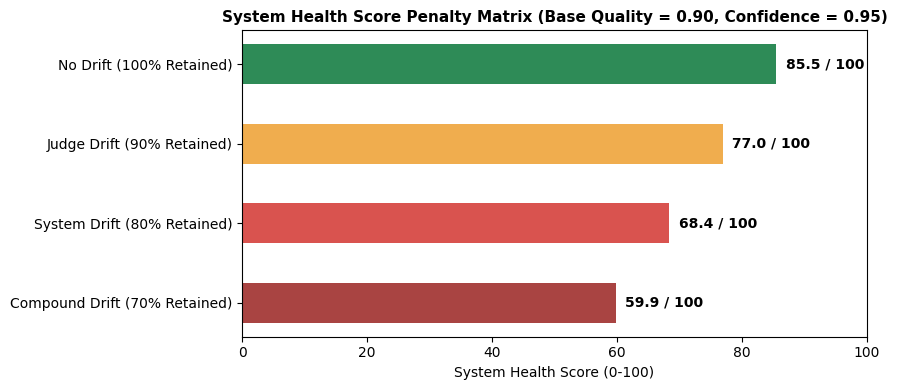

In [8]:
# System Health Score impact across all Drift States (Quality=0.90, Confidence=0.95)
states = [DriftState.NO_DRIFT, DriftState.JUDGE_DRIFT, DriftState.SYSTEM_DRIFT, DriftState.COMPOUND_DRIFT]
scores = [compute_system_health_score(0.90, 0.95, st) for st in states]
state_labels = [
    "No Drift (100% Retained)",
    "Judge Drift (90% Retained)",
    "System Drift (80% Retained)",
    "Compound Drift (70% Retained)"
]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2e8b57", "#f0ad4e", "#d9534f", "#a94442"]

bars = ax.barh(state_labels, scores, color=colors, height=0.5)
ax.set_xlim(0, 100)
ax.set_xlabel("System Health Score (0-100)")
ax.set_title("System Health Score Penalty Matrix (Base Quality = 0.90, Confidence = 0.95)", fontweight="bold", fontsize=11)

for bar in bars:
    xval = bar.get_width()
    ax.text(xval + 1.5, bar.get_y() + bar.get_height()/2, f"{xval:.1f} / 100", ha='left', va='center', fontweight='bold')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. End-to-End Validation & Edge Cases

In [9]:
# Empty anchor set edge case validation
empty_anchor_set = AnchorSet(name="empty")
try:
    empty_anchor_set.get_reference_scores("groundedness")
    raise AssertionError("Should have raised ValueError on missing metric.")
except ValueError as exc:
    print(f"PASS: Empty anchor set correctly rejected ({exc}).")

# End-to-end payload execution to health score calculation
sample_results = [
    MetricResult(
        metric_name="groundedness",
        trace_id=uuid4(),
        score=0.92,
        confidence=0.88,
        computed_at=datetime.now(timezone.utc),
    ),
    MetricResult(
        metric_name="groundedness",
        trace_id=uuid4(),
        score=0.88,
        confidence=0.88,
        computed_at=datetime.now(timezone.utc),
    ),
]

mean_quality = float(np.mean([r.score for r in sample_results]))
mean_confidence = float(np.mean([r.confidence for r in sample_results]))

e2e_health = compute_system_health_score(
    mean_quality_score=mean_quality,
    statistical_confidence=mean_confidence,
    attribution_state=DriftState.NO_DRIFT,
)

assert e2e_health == 79.2
print(f"✅ End-to-end integration test passed (System Health Score: {e2e_health}).")

PASS: Empty anchor set correctly rejected (Metric 'groundedness' missing from anchor set.).
✅ End-to-end integration test passed (System Health Score: 79.2).


## 7. Production Extraction Map

| Notebook Component | Target Source File | Status |
|---|---|---|
| `AnchorItem`, `AnchorSet` | `src/nirizan/trust/anchor_set.py` | New — Phase 5 extraction |
| `AttributionEngine`, `DriftState` | `src/nirizan/trust/attribution.py` | New — Phase 5 extraction |
| `BehavioralAnchorDetector` | `src/nirizan/metrics/behavioral_anchor.py` | New — Phase 5 extraction |
| `compute_system_health_score` | `src/nirizan/reporting/health_score.py` | New — Phase 5 extraction |